# Deep Learning

*(2016, By Ian Goodfellow, Yoshua Bengio, Aaron Courville)*

___

Current page : 202

## Part II : Deep Network : Modern Practices

___

## Chapter 6. Deep Feedforward Network

### Example 1

Approxmating $x^2$
- ReLU activation function
- 2 layers (64 neurons, 64 neurons)

Epoch 0: Loss = 16.687759
Epoch 500: Loss = 0.000160
Epoch 1000: Loss = 0.000031
Epoch 1500: Loss = 0.000018


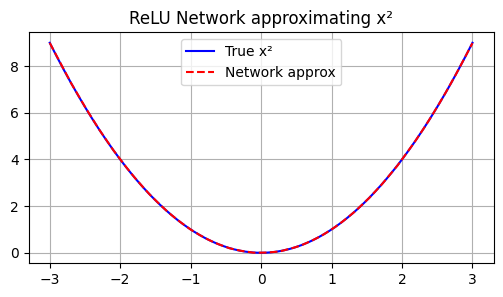

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# --- Data ---
x_train = torch.linspace(-3, 3, 500).reshape(-1, 1)
y_train = x_train ** 2

# --- Network ---
class Net(nn.Module):
    def __init__(self, hidden_size=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, 1)    # no activation at output
        )
    def forward(self, x):
        return self.net(x)

model = nn.Sequential(
    nn.Linear(1, 64), nn.ReLU(),
    nn.Linear(64, 64), nn.ReLU(),
    nn.Linear(64, 1)
)

# --- Training ---
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn   = nn.MSELoss()

for epoch in range(2000):
    y_pred = model(x_train)
    loss   = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.6f}")

# --- Plot ---
x_test  = torch.linspace(-3, 3, 300).reshape(-1, 1)
y_pred  = model(x_test).detach()

plt.figure(figsize=(6, 3))
plt.plot(x_test, x_test**2,  label='True x²',       color='blue')
plt.plot(x_test, y_pred,     label='Network approx', color='red', linestyle='--')
plt.legend()
plt.title('ReLU Network approximating x²')
plt.grid()
plt.show()


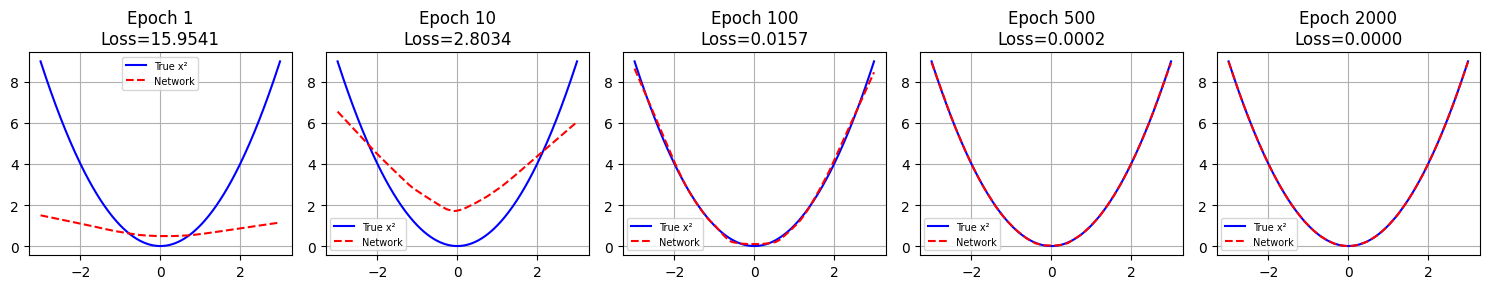

In [8]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# --- Data ---
x_train = torch.linspace(-3, 3, 500).reshape(-1, 1)
y_train = x_train ** 2

# --- Model ---
model = nn.Sequential(
    nn.Linear(1, 64), nn.ReLU(),
    nn.Linear(64, 64), nn.ReLU(),
    nn.Linear(64, 1)
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn   = nn.MSELoss()

# --- Plot at these epochs ---
plot_epochs = [1, 10, 100, 500, 2000]

x_test = torch.linspace(-3, 3, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, len(plot_epochs), figsize=(15, 3))

# --- Training ---
for epoch in range(1, 2001):
    y_pred = model(x_train)
    loss   = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch in plot_epochs:
        ax    = axes[plot_epochs.index(epoch)]
        y_out = model(x_test).detach()
        ax.plot(x_test, x_test**2,  label='True x²',   color='blue')
        ax.plot(x_test, y_out,      label='Network',    color='red', linestyle='--')
        ax.set_title(f'Epoch {epoch}\nLoss={loss.item():.4f}')
        ax.legend(fontsize=7)
        ax.grid()

plt.tight_layout()
plt.show()
